In [1]:
import numpy as np
from numpy.random import default_rng
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Rectangle
from tqdm.notebook import tqdm
from scipy.stats import sem, norm, ttest_ind
from my_utils import *
from sklearn.linear_model import RidgeCV

from pathlib import Path
import sys
import warnings

In [2]:
modelpath = Path('../model')
sys.path.append(str(modelpath))
import config.config as config

# a

In [3]:
locals().update(config_colors())
major_formatter = FuncFormatter(my_tickformatter)

fontsize = 7
lw = 1

In [4]:
def simple_KF(b_last, a, o_t, pro_std, obs_std):
    STATE_DIM = 2
    ACTION_DIM = 1
    OBS_DIM = 1

    Q = np.zeros([STATE_DIM, STATE_DIM])
    Q[-1, -1] = pro_std**2
    R = np.eye(OBS_DIM) * obs_std**2

    A = np.array([[1, 1], [0, 0]])
    B = np.array([0, 1]).reshape(-1, 1)
    H = np.array([0, 1]).reshape(1, -1)
    
    b_last, P_last = b_last
    # predict
    b_ = A @ b_last + B @ a
    P_ = A @ P_last @ A.T + Q
    # update
    y_t = o_t - H @ b_
    S_t = H @ P_ @ H.T + R
    K_t = P_ @ H.T @ np.linalg.inv(S_t)
    b_t = b_ + K_t @ y_t
    P_t = (np.eye(STATE_DIM) - K_t @ H) @ P_
    b = b_t, P_t
    
    return b

In [5]:
noises = [(1.5, 1e5), (1e5, 1), (1.5, 1)]
steps = 2
b_means = []
b_uncertains = []
for noise in noises:
    b = (np.array([0, 0]).reshape(-1, 1), np.zeros((2, 2)))
    a = np.array([-3.]).reshape(-1, 1)
    o_t = np.array([3.]).reshape(-1, 1)
    for _ in range(steps):
        b = simple_KF(b, a, o_t, pro_std=noise[0], obs_std=noise[1])
    b_means.append(b[0])
    b_uncertains.append(b[1])

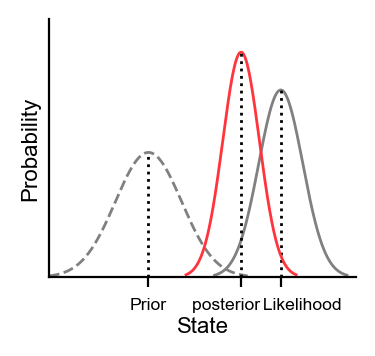

In [6]:
width = 1.7
height = 1.6

mus = [round(b_mean[0][0], 1) for b_mean in b_means]
sigmas = [np.sqrt(b_uncertain[0, 0]) for b_uncertain in b_uncertains]

xticklabels = ['Prior', '         Likelihood', 'posterior      ']
colors = ['gray', 'gray', belief_c]

with initiate_plot(width, height, 200) as fig:
    ax = fig.add_subplot(111)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.xticks(mus[:len(xticklabels)], xticklabels, fontsize=fontsize - 0.7)
    ax.axes.yaxis.set_ticks([])
    ax.set_xlabel('State', fontsize=fontsize + 1)
    ax.set_ylabel('Probability', fontsize=fontsize + 1)
    ax.set_xlim([-7.5, 6.4]); ax.set_ylim([0, 0.55])
    ax.yaxis.set_label_coords(-0.03, 0.5)
    ax.xaxis.set_label_coords(0.5, -0.15)
    
    for idx, (mu, sigma) in enumerate(zip(mus, sigmas)):
        x_axis = np.linspace(mu - 3 * sigma, mu + 3 * sigma, 1001)
        prob = norm.pdf(x_axis, mu, sigma)
        ls = '--' if idx == 0 else '-'
        ax.plot(x_axis, prob, lw=lw, c=colors[idx], ls=ls, clip_on=False)
        if idx < 3:
            ax.plot(np.linspace(mu, mu), np.linspace(0, prob.max()), 
                    lw=lw, c='k', ls=':', clip_on=False)
    
    fig.tight_layout(pad=0.1)
    
    #plt.savefig('C:/Users/rz31/Desktop/paper_figures/figure7/raw/{name}.pdf'.format(
    #    name='belief_update'), orientation='portrait', format='pdf', transparent=True)

# c

## Choose agents

In [7]:
from Actor3 import Actor as Actor3; from Critic5 import Critic as Critic5

pro_stds = [str(i) for i in [0, 0.1, 0.2, 0.3]]; obs_stds = pro_stds.copy()
agent_noises = ['_'.join(list(i)) for i in cartesian_prod(pro_stds, obs_stds)]
progress_noise_agents_path = Path.cwd().parents[1] / 'agents' / 'Actor3Critic5' / 'gain_control'
MAX_TRAINING_T = 1e5

In [8]:
def select_noise_agents(progress_agents_path, agent_noises, MAX_TRAINING_T, task='gain'):  
    seeds = [[''.join(filter(str.isdigit, file.stem.split('_')[1]))
              for file in (Path.cwd().parent / 'model' / 'training_curve' / f'{task}_control' / agent_noise).glob('*')] 
             for agent_noise in agent_noises]
    
    agent_paths = []; agent_files = []
    for agent_noise, seeds_ in zip(agent_noises, seeds): # loop each agent
        agent_path = []; agent_file = []
        for seed in seeds_:
            perform_file_path = Path.cwd().parent / 'model' / 'training_curve' / f'{task}_control' / agent_noise\
                                    / f'Actor3Critic5_seed{seed}.csv'
            perform_file = pd.read_csv(perform_file_path)
            perform_file = perform_file[(perform_file.episode > 0) & (perform_file.episode < MAX_TRAINING_T)]
            best_episode = perform_file.episode.unique()[np.sum([perform_file[perform_file.task == task].reward_rate 
                                      for task in perform_file.task.unique()], axis=0).argmax()]
            
            agent_path.append(progress_agents_path / agent_noise / f'seed{seed}')
            agent_file.append(list(agent_path[-1].glob(f'*-{best_episode}.*'))[0].stem.split('.')[0])
        agent_paths.append(agent_path); agent_files.append(agent_file)
    
    
    return agent_paths, agent_files

In [9]:
noise_agent_paths_gain, noise_agent_files_gain = select_noise_agents(progress_noise_agents_path, agent_noises, 
                                                                     MAX_TRAINING_T, task='gain')

In [10]:
from Agent_LSTM import *
from Environment import Env

In [11]:
def LSTM_agent_simulation_gain(agent, target_positions, gains, arg):
    reset_seeds(0)
    env = Env(arg)
    agent.bstep.obs_noise_range = arg.obs_noise_range

    pos_x = []; pos_x_end = []; pos_y = []; pos_y_end = []
    head_dir = []; head_dir_end = []; pos_r = []; pos_theta = []; pos_r_end = []; pos_theta_end = []; 
    pos_v = []; pos_w = []
    target_x = []; target_y = []; target_r = []; target_theta = []
    rewarded = []; relative_radius = []; relative_angle = []
    action_v = []; action_w = []
    relative_radius_end = []; relative_angle_end = []
    steps = []; state_ = []; action_ = []

    for target_position, gain in tqdm(zip(target_positions, gains)):
        cross_start_threshold = False
        x = env.reset(target_position=target_position, pro_gains=gain)
        agent.bstep.reset(env.pro_gains)
        last_action = torch.zeros([1, 1, arg.ACTION_DIM])
        last_action_raw = last_action.clone()

        state = torch.cat([x[-arg.OBS_DIM:].view(1, 1, -1), last_action,
                           env.target_position_obs.view(1, 1, -1)], dim=2).to(arg.device)

        hidden_in = None

        true_states = []
        actions = []
        states = []
        
        for t in range(arg.EPISODE_LEN):
            if not cross_start_threshold and (last_action_raw.abs() > arg.TERMINAL_ACTION).any():
                cross_start_threshold = True
                
            action, action_raw, hidden_out = agent.select_action(state, hidden_in, action_noise=None)
            next_x, reached_target, _ = env(x, action, t)
            next_ox = agent.bstep(next_x)
            next_state = torch.cat([next_ox.view(1, 1, -1), action,
                                    env.target_position_obs.view(1, 1, -1)], dim=2).to(arg.device)

            is_stop = env.is_stop(x, action)

            true_states.append(x)
            states.append(state)
            actions.append(action)
            
            last_action_raw = action_raw
            state = next_state
            x = next_x
            hidden_in = hidden_out

            if is_stop and cross_start_threshold:
                break

        # Trial end
        pos_x_temp, pos_y_temp, head_dir_temp, pos_v_temp, pos_w_temp \
                    = torch.chunk(torch.cat(true_states, dim=1), x.shape[0], dim=0)
        pos_x.append(pos_x_temp.view(-1).numpy() * arg.LINEAR_SCALE)
        pos_y.append(pos_y_temp.view(-1).numpy() * arg.LINEAR_SCALE)
        pos_x_end.append(pos_x[-1][-1])
        pos_y_end.append(pos_y[-1][-1])
        head_dir.append(np.rad2deg(head_dir_temp.view(-1).numpy()))
        pos_v.append(pos_v_temp.view(-1).numpy() * arg.LINEAR_SCALE)
        pos_w.append(np.rad2deg(pos_w_temp.view(-1).numpy()))
        head_dir_end.append(head_dir[-1][-1])

        rho, phi = cart2pol(pos_x[-1], pos_y[-1])
        pos_r.append(rho)
        pos_theta.append(np.rad2deg(phi))
        pos_r_end.append(rho[-1])
        pos_theta_end.append(np.rad2deg(phi[-1]))

        target_x.append(target_position[0].item() * arg.LINEAR_SCALE)
        target_y.append(target_position[1].item() * arg.LINEAR_SCALE)
        tar_rho, tar_phi = cart2pol(target_x[-1], target_y[-1])
        target_r.append(tar_rho)
        target_theta.append(np.rad2deg(tar_phi))
        
        state_.append(torch.cat(states))

        action_.append(torch.cat(actions))
        action_v_temp, action_w_temp = torch.chunk(torch.cat(actions).squeeze(1), 
                                                   action.shape[-1], dim=1)
        action_v.append(action_v_temp.view(-1).numpy())
        action_w.append(action_w_temp.view(-1).numpy())
        
        relative_r, relative_ang = get_relative_r_ang(pos_x[-1], pos_y[-1], head_dir[-1], 
                                                      target_x[-1], target_y[-1])
        relative_radius.append(relative_r)
        relative_angle.append(np.rad2deg(relative_ang))
        relative_radius_end.append(relative_r[-1])
        relative_angle_end.append(np.rad2deg(relative_ang[-1]))
        rewarded.append((reached_target & is_stop).item())
        
        steps.append(np.arange(relative_r.size))

    agent.bstep.obs_noise_range = config.ConfigGain().obs_noise_range
    
    return(pd.DataFrame().assign(pos_x=pos_x, pos_y=pos_y, pos_x_end=pos_x_end, pos_y_end=pos_y_end,
                                 head_dir=head_dir, head_dir_end=head_dir_end, 
                                 pos_r=pos_r, pos_theta=pos_theta, 
                                 pos_r_end=pos_r_end, pos_theta_end=pos_theta_end, pos_v=pos_v, 
                                 pos_w=pos_w, target_x=target_x, target_y=target_y, 
                                 target_r=target_r,
                                 target_theta=target_theta, rewarded=rewarded,
                                 relative_radius=relative_radius, relative_angle=relative_angle,
                                 action_v=action_v, action_w=action_w, 
                                 relative_radius_end=relative_radius_end,
                                 relative_angle_end=relative_angle_end,
                                 steps=steps, gain_v=torch.stack(gains)[:, 0].numpy(),
                                 gain_w=torch.stack(gains)[:, 1].numpy(), 
                                 state=state_, action=action_))

In [12]:
SAMPLE_SIZE = 2000

reset_seeds(0)
arg = config.ConfigGain()
arg.device = 'cpu'
arg.process_gain_range = [3, 4.0001]
env = Env(arg)
target_positions = []
gains = []

for _ in range(SAMPLE_SIZE):
    __ = env.reset()
    target_positions.append(env.target_position)
    gains.append(env.pro_gains)

In [13]:
noise_agents_gain = []; noise_agent_trajectories_gain = []
for idx, agent_noise in enumerate(agent_noises):
    agents_ = []; agent_trajectories_ = []
    arg = config.ConfigGainControl(pro_noise=float(agent_noise.split('_')[0]), 
                                   obs_noise=float(agent_noise.split('_')[1]))
    arg.device = 'cpu'
    arg.process_gain_range = [3, 4.0001]
    for agent_path, agent_file in zip(noise_agent_paths_gain[idx], noise_agent_files_gain[idx]):
        agent = Agent(arg, Actor3, Critic5)
        agent.data_path = agent_path
        agent.load(agent_file, load_memory=False, load_optimzer=False)
        agents_.append(agent)
        agent_trajectories_.append(LSTM_agent_simulation_gain(agent, target_positions, gains, arg))
    noise_agents_gain.append(agents_)
    noise_agent_trajectories_gain.append(agent_trajectories_)

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [14]:
def compute_roc(max_reward_boundary, dfs):
    hypo_reward_boundaries = np.arange(max_reward_boundary)
    targets = dfs[0][0][['target_x', 'target_y']].values
    shuffled_targets = targets.copy()
    rng = default_rng(1); rng.shuffle(shuffled_targets, axis=0)
    
    ydata_subjects = []; xdata_subjects = []
    for dfs_ in dfs:
        ydata_seeds = []; xdata_seeds = []
        for df in dfs_:
            ydata = []; xdata = []
            for reward_boundary in hypo_reward_boundaries:
                ydata.append((np.linalg.norm(df[['pos_x_end', 'pos_y_end']].values - targets, axis=1) 
                              < reward_boundary).sum() / len(df))
                xdata.append((np.linalg.norm(df[['pos_x_end', 'pos_y_end']].values - shuffled_targets, axis=1) 
                              < reward_boundary).sum() / len(df))
            ydata_seeds.append(ydata); xdata_seeds.append(xdata)
        ydata_subjects.append(ydata_seeds); xdata_subjects.append(xdata_seeds)
        
    auc_data = [[np.trapz(ydata_subjects[agent_idx][idx], xdata_subjects[agent_idx][idx]) 
                 for idx in range(len(dfs[agent_idx]))] for agent_idx in range(len(dfs))]
    auc_mean = np.array([np.mean(i) for i in auc_data]).reshape(len(obs_stds), len(pro_stds))
    auc_sem = np.array([sem(i) for i in auc_data]).reshape(len(obs_stds), len(pro_stds))
    
    return xdata_subjects, ydata_subjects, auc_data, auc_mean, auc_sem

In [15]:
max_reward_boundary = round(max([df.relative_radius_end.max() 
                                 for dfs in noise_agent_trajectories_gain for df in dfs])) + 1
_, _, auc_noise_gain, auc_noise_gain_mean, auc_noise_gain_sem = compute_roc(max_reward_boundary, 
                                                                            noise_agent_trajectories_gain)

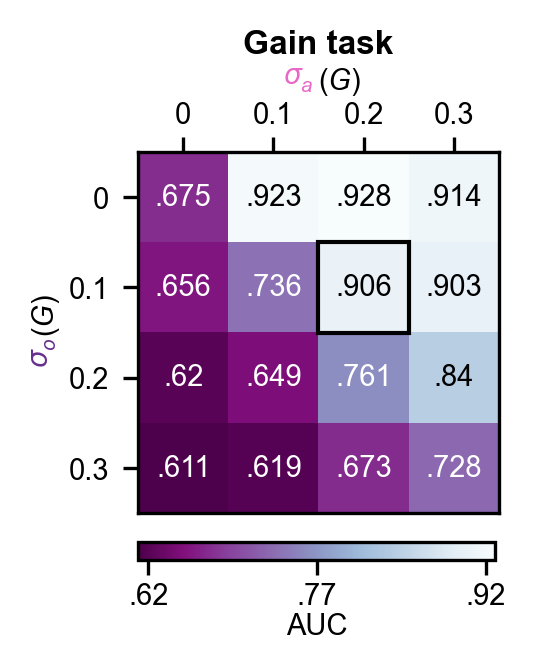

In [21]:
xticks = np.arange(len(obs_stds)); xticklabels = obs_stds
yticks = np.arange(len(pro_stds)); yticklabels = pro_stds
width = 1.7
height = 2.2

with initiate_plot(width, height, 300) as fig:
    ax = fig.add_subplot(111)
    ax.set_title('Gain task', fontsize=fontsize + 1, fontweight='bold', pad=3)
    plt.xticks(xticks, xticklabels, fontsize=fontsize)
    plt.yticks(yticks, yticklabels, fontsize=fontsize)
    ax.set_xlabel(r'$\sigma_a$', fontsize=fontsize, c=motor_c)
    ax.set_ylabel(r'$\sigma_o$', fontsize=fontsize, c=sensory_c)
    ax.xaxis.set_label_coords(0.445, 1.24)
    ax.yaxis.set_label_coords(-0.22, 0.445)
        
    cmatplot = ax.matshow(auc_noise_gain_mean, cmap='BuPu_r') 
    ax.tick_params(axis='x', which='major', pad=2, bottom=False)
    cbaxes = ax.inset_axes([0, -0.13, 0.99, 0.05]) 
    cbar = fig.colorbar(cmatplot, cax=cbaxes, orientation='horizontal')
    cbar.ax.tick_params(labelsize=fontsize, pad=2)
    cbar_ticks = [0.62, 0.77, 0.92]
    cbar.set_ticks(cbar_ticks)
    cbar.set_label('AUC', fontsize=fontsize)
    cbar.ax.xaxis.set_label_coords(0.5, -2.9)
    cbar.ax.xaxis.set_major_formatter(major_formatter)
    
    rect = Rectangle(xy=(1.5, 0.5), width=1, height=1, fill=False, ec='k', lw=1)
    ax.add_patch(rect)
    
    for iy, y in enumerate(np.arange(len(yticks))):
        for ix, x in enumerate(np.arange(len(xticks))):
            v = round(auc_noise_gain_mean[iy][ix], 3)
            c = 'k' if v > 0.77 else 'w' 
            ax.text(x, y, s='.' + str(v).split('.')[1], fontsize=fontsize, 
                    c=c, va='center', ha='center')
            
    ax.text(1.5, -1.2, '$(G)$', fontsize=fontsize)
    ax.text(-1.7, 1.45, '$(G)$', fontsize=fontsize, rotation='vertical')
    
    fig.tight_layout(pad=0.3, rect=(-0.01, 0.02, 0.99, 1.02))
    
    #plt.savefig('C:/Users/rz31/Desktop/paper_figures/figure7/raw/{name}.pdf'.format(
    #             name='auc_gain'), orientation='portrait', format='pdf', transparent=True)

## sup a

In [22]:
def get_neural_response(agent, df):
    responses = []
    with torch.no_grad():
        for _, trial in df.iterrows():
            response = agent.actor.rnn(trial.state)[0]
            responses.append(response.squeeze(1))
        df['response'] = responses
    return torch.cat(responses).numpy()

In [23]:
train_frac = 0.7
def fit_decoder(trajectory, start_idx=0, variables=['pos_x', 'pos_y']):
    key = 'response'
    train_trajectory = trajectory[:round(len(trajectory) * train_frac)]
    train_X = np.vstack([x[start_idx:] for _, x in train_trajectory[key].iteritems()])
    test_trajectory = trajectory[round(len(trajectory) * train_frac):]
    test_X = np.vstack([x[start_idx:] for _, x in test_trajectory[key].iteritems()])
    
    y = train_trajectory[variables].values
    train_y = np.vstack([np.hstack([v[start_idx:] for v in y[:, i]]) for i in range(y.shape[1])]).T
    y = test_trajectory[variables].values
    test_y = np.vstack([np.hstack([v[start_idx:] for v in y[:, i]]) for i in range(y.shape[1])]).T
    
    decoder = RidgeCV()
    decoder.fit(train_X, train_y)
    
    return decoder, test_X, test_y

In [24]:
_ = [[get_neural_response(agent, df) for agent, df in zip(agents_, dfs)] 
     for agents_, dfs in zip(noise_agents_gain, noise_agent_trajectories_gain)]

In [25]:
decoders_gain = [list(map(fit_decoder, dfs)) for dfs in noise_agent_trajectories_gain]
decoding_errors_gain = [[np.linalg.norm(deco[0].predict(deco[1]) - deco[2], axis=1).mean() for deco in decoder]
                        for decoder in decoders_gain]
decoding_errors_gain_mean = np.array([np.mean(v) for v in decoding_errors_gain]).reshape(len(obs_stds), len(pro_stds))
decoding_errors_gain_sem = np.array([sem(v) for v in decoding_errors_gain]).reshape(len(obs_stds), len(pro_stds))

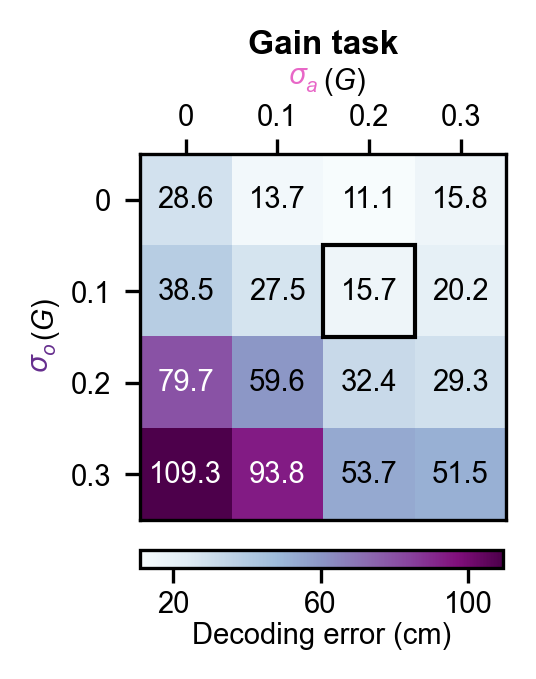

In [26]:
xticks = np.arange(len(obs_stds)); xticklabels = obs_stds
yticks = np.arange(len(pro_stds)); yticklabels = pro_stds
width = 1.7
height = 2.2

with initiate_plot(width, height, 300) as fig:
    ax = fig.add_subplot(111)
    ax.set_title('Gain task', fontsize=fontsize + 1, fontweight='bold', pad=3)
    plt.xticks(xticks, xticklabels, fontsize=fontsize)
    plt.yticks(yticks, yticklabels, fontsize=fontsize)
    ax.set_xlabel(r'$\sigma_a$', fontsize=fontsize, c=motor_c)
    ax.set_ylabel(r'$\sigma_o$', fontsize=fontsize, c=sensory_c)
    ax.xaxis.set_label_coords(0.445, 1.24)
    ax.yaxis.set_label_coords(-0.22, 0.445)
        
    cmatplot = ax.matshow(decoding_errors_gain_mean, cmap='BuPu') 
    ax.tick_params(axis='x', which='major', pad=2, bottom=False)
    cbaxes = ax.inset_axes([0, -0.13, 0.99, 0.05]) 
    cbar = fig.colorbar(cmatplot, cax=cbaxes, orientation='horizontal')
    cbar.ax.tick_params(labelsize=fontsize, pad=2)
    cbar_ticks = [20, 60, 100]
    cbar.set_ticks(cbar_ticks)
    cbar.set_label('Decoding error (cm)', fontsize=fontsize)
    cbar.ax.xaxis.set_label_coords(0.5, -2.9)
    cbar.ax.xaxis.set_major_formatter(major_formatter)
    
    rect = Rectangle(xy=(1.5, 0.5), width=1, height=1, fill=False, ec='k', lw=1)
    ax.add_patch(rect)
    
    for iy, y in enumerate(np.arange(len(yticks))):
        for ix, x in enumerate(np.arange(len(xticks))):
            v = round(decoding_errors_gain_mean[iy][ix], 1)
            c = 'k' if v < 70 else 'w'
            ax.text(x, y, s=v, fontsize=fontsize, 
                    c=c, va='center', ha='center')
            
    ax.text(1.5, -1.2, '$(G)$', fontsize=fontsize)
    ax.text(-1.7, 1.45, '$(G)$', fontsize=fontsize, rotation='vertical')
    
    fig.tight_layout(pad=0.3, rect=(-0.01, 0.02, 0.99, 1.02))
    
    #plt.savefig('C:/Users/rz31/Desktop/paper_figures/figure7/raw/{name}.pdf'.format(
    #             name='sup_decoding_error_gain'), orientation='portrait', format='pdf', transparent=True)

## sup c

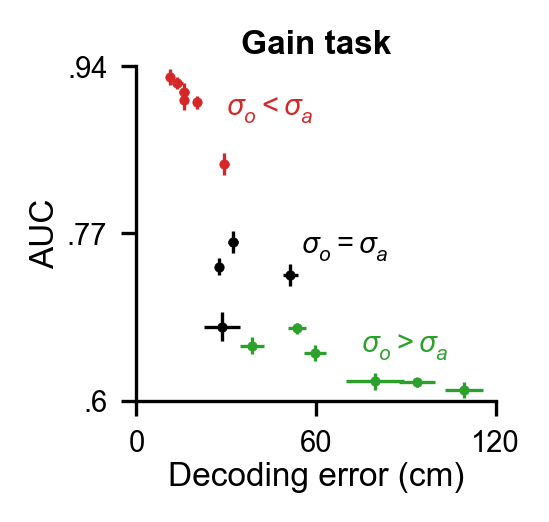

In [27]:
width = 1.7; height = 1.6
marker = 'o'; marker_size = 5; marker_lw = lw * 0.2

xticks = [0, 60, 120]
yticks = [0.6, 0.77, 0.94]

indices_upper, indices_lower, indices_diag = get_index_upper_lower_diag(auc_noise_gain_mean)
colors = ['C3', 'C2', 'k']

with initiate_plot(width, height, 300) as fig:
    ax = fig.add_subplot(1, 1, 1)
    ax.set_title('Gain task', fontsize=fontsize + 1, fontweight='bold', pad=3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.xticks(xticks, fontsize=fontsize)
    plt.yticks(yticks, fontsize=fontsize)
    ax.set_xlabel('Decoding error (cm)', fontsize=fontsize + 1)
    ax.set_ylabel(r'AUC', fontsize=fontsize + 1)
    ax.set_xlim(xticks[0], xticks[-1])
    ax.set_ylim(yticks[0], yticks[-1])
    ax.xaxis.set_label_coords(0.5, -0.18)
    ax.yaxis.set_label_coords(-0.21, 0.5)
    ax.xaxis.set_major_formatter(major_formatter)
    ax.yaxis.set_major_formatter(major_formatter)

    for agent_idx in range(auc_noise_gain_mean.size):
        if agent_idx in indices_upper:
            c = colors[0]
        elif agent_idx in indices_lower:
            c = colors[1]
        elif agent_idx in indices_diag:
            c = colors[2]

        ax.scatter(decoding_errors_gain_mean.flatten()[agent_idx], auc_noise_gain_mean.flatten()[agent_idx], 
                   s=marker_size, lw=marker_lw, marker=marker, clip_on=False, c=c)
        ax.errorbar(decoding_errors_gain_mean.flatten()[agent_idx], auc_noise_gain_mean.flatten()[agent_idx], 
                    yerr=auc_noise_gain_sem.flatten()[agent_idx], xerr=decoding_errors_gain_sem.flatten()[agent_idx], 
                    c=c, lw=lw * 0.8, ls='none') 
        
    ax.text(30, 0.89, '$\sigma_o<\sigma_a$', fontsize=fontsize, c=colors[0])
    ax.text(55, 0.75, '$\sigma_o=\sigma_a$', fontsize=fontsize, c=colors[2])
    ax.text(75, 0.65, '$\sigma_o>\sigma_a$', fontsize=fontsize, c=colors[1])
    
           
    fig.tight_layout(pad=0.15, rect=(0, 0, 1, 1))

    #plt.savefig('C:/Users/rz31/Desktop/paper_figures/figure7/raw/{name}.pdf'.format(
    #    name='sup_corr_gain'), orientation='portrait', format='pdf', transparent=True)

# d

In [16]:
noise_agent_paths_pert, noise_agent_files_pert = select_noise_agents(progress_noise_agents_path, agent_noises, 
                                                                     MAX_TRAINING_T, task='perturbation')

In [17]:
def LSTM_agent_simulation_pert(arg, agent, target_positions, perturb_peaks, perturb_start_time_oris):
    reset_seeds(0)
    env = Env(arg)
    agent.bstep.obs_noise_range = arg.obs_noise_range

    pos_x = []; pos_y = []; pos_x_end = []; pos_y_end = []; head_dir = []; head_dir_end = []; pos_r = []
    pos_theta = []; pos_r_end = []; pos_theta_end = []; pos_v = []; pos_w = []
    target_x = []; target_y = []; target_r = []; target_theta = []
    rewarded = []; relative_radius = []; relative_angle = []
    action_v = []; action_w = []
    relative_radius_end = []; relative_angle_end = []; steps = []
    perturb_v = []; perturb_w = []; perturb_v_gauss = []; perturb_w_gauss = []
    state_ = []; action_ = []

    for target_position, perturb_peak, perturb_start_time_ori in tqdm(zip(target_positions, perturb_peaks,
                                                                          perturb_start_time_oris)):
        cross_start_threshold = False
        x = env.reset(target_position=target_position, perturbation_velocities=perturb_peak,
                      perturbation_start_t=perturb_start_time_ori)
        agent.bstep.reset(env.pro_gains)
        last_action = torch.zeros([1, 1, arg.ACTION_DIM])
        last_action_raw = last_action.clone()

        state = torch.cat([x[-arg.OBS_DIM:].view(1, 1, -1), last_action,
                           env.target_position.view(1, 1, -1)], dim=2).to(arg.device)

        hidden_in = None

        true_states = []
        actions = []
        states = []
        perturbations = []
        
        for t in range(arg.EPISODE_LEN):
            if not cross_start_threshold and (last_action_raw.abs() > arg.TERMINAL_ACTION).any():
                cross_start_threshold = True
            
            action, action_raw, hidden_out = agent.select_action(state, hidden_in, action_noise=None)
            next_x, reached_target, _ = env(x, action, t)
            next_ox = agent.bstep(next_x)
            next_state = torch.cat([next_ox.view(1, 1, -1), action,
                                    env.target_position_obs.view(1, 1, -1)], dim=2).to(arg.device)

            is_stop = env.is_stop(x, action)

            true_states.append(x)
            states.append(state)
            actions.append(action)
            perturbations.append(torch.stack((env.perturbation_vt, env.perturbation_wt)))
            
            last_action_raw = action_raw
            state = next_state
            x = next_x
            hidden_in = hidden_out

            if is_stop and cross_start_threshold:
                break

        # Trial end
        pos_x_temp, pos_y_temp, head_dir_temp, pos_v_temp, pos_w_temp \
                    = torch.chunk(torch.cat(true_states, dim=1), x.shape[0], dim=0)
        pos_x.append(pos_x_temp.view(-1).numpy() * arg.LINEAR_SCALE)
        pos_y.append(pos_y_temp.view(-1).numpy() * arg.LINEAR_SCALE)
        pos_x_end.append(pos_x[-1][-1])
        pos_y_end.append(pos_y[-1][-1])
        head_dir.append(np.rad2deg(head_dir_temp.view(-1).numpy()))
        pos_v.append(pos_v_temp.view(-1).numpy() * arg.LINEAR_SCALE)
        pos_w.append(np.rad2deg(pos_w_temp.view(-1).numpy()))
        head_dir_end.append(head_dir[-1][-1])

        rho, phi = cart2pol(pos_x[-1], pos_y[-1])
        pos_r.append(rho)
        pos_theta.append(np.rad2deg(phi))
        pos_r_end.append(rho[-1])
        pos_theta_end.append(np.rad2deg(phi[-1]))

        target_x.append(target_position[0].item() * arg.LINEAR_SCALE)
        target_y.append(target_position[1].item() * arg.LINEAR_SCALE)
        tar_rho, tar_phi = cart2pol(target_x[-1], target_y[-1])
        target_r.append(tar_rho)
        target_theta.append(np.rad2deg(tar_phi))
        
        state_.append(torch.cat(states))

        action_.append(torch.cat(actions))
        action_v_temp, action_w_temp = torch.chunk(torch.cat(actions).squeeze(1), 
                                                   action.shape[-1], dim=1)
        action_v.append(action_v_temp.view(-1).numpy())
        action_w.append(action_w_temp.view(-1).numpy())
        
        relative_r, relative_ang = get_relative_r_ang(pos_x[-1], pos_y[-1], head_dir[-1], 
                                                      target_x[-1], target_y[-1])
        relative_radius.append(relative_r)
        relative_angle.append(np.rad2deg(relative_ang))
        relative_radius_end.append(relative_r[-1])
        relative_angle_end.append(np.rad2deg(relative_ang[-1]))
        rewarded.append((reached_target & is_stop).item())
        
        steps.append(np.arange(relative_r.size))
        
        perturb_v.append(torch.stack(perturbations)[:, 0].numpy() * arg.LINEAR_SCALE)
        perturb_w.append(np.rad2deg(torch.stack(perturbations)[:, 1].numpy()))
        perturb_v_gauss.append(env.gaussian_v_array.numpy() * arg.LINEAR_SCALE)
        perturb_w_gauss.append(np.rad2deg(env.gaussian_w_array.numpy()))
        
    agent.bstep.obs_noise_range = config.ConfigGain().obs_noise_range

    return(pd.DataFrame().assign(pos_x=pos_x, pos_y=pos_y, pos_x_end=pos_x_end, pos_y_end=pos_y_end, 
                                 head_dir=head_dir, head_dir_end=head_dir_end, 
                                 pos_r=pos_r, pos_theta=pos_theta, 
                                 pos_r_end=pos_r_end, pos_theta_end=pos_theta_end, pos_v=pos_v, 
                                 pos_w=pos_w, target_x=target_x, target_y=target_y, 
                                 target_r=target_r,
                                 target_theta=target_theta, rewarded=rewarded,
                                 relative_radius=relative_radius, relative_angle=relative_angle,
                                 action_v=action_v, action_w=action_w, 
                                 relative_radius_end=relative_radius_end,
                                 relative_angle_end=relative_angle_end, steps=steps,
                                 perturb_v=perturb_v, perturb_w=perturb_w,
                                 perturb_vpeak=torch.stack(perturb_peaks)[:, 0].numpy() * arg.LINEAR_SCALE,
                                 perturb_wpeak=np.rad2deg(torch.stack(perturb_peaks)[:, 1].numpy()),
                                 perturb_start_time=torch.stack(perturb_start_time_oris).numpy(),
                                 perturb_v_gauss=perturb_v_gauss, perturb_w_gauss=perturb_w_gauss,
                                 gain_v=[env.process_gain_default[0].item() for _ in range(len(pos_x))],
                                 gain_w=[env.process_gain_default[1].item() for _ in range(len(pos_x))],
                                 state=state_, action=action_))

In [18]:
reset_seeds(0)
arg = config.ConfigPerturb(exclude_perturb=np.hstack([np.array([-100, 100]) / arg.LINEAR_SCALE, 
                                                      np.deg2rad([-60, 60])]))
arg.device = 'cpu'
arg.perturbation_velocity_range = arg.perturbation_velocity_range_large
env = Env(arg)
perturb_peaks = []; perturb_start_time = []
for _ in range(SAMPLE_SIZE):
    __ = env.reset()
    perturb_peaks.append(env.perturbation_velocities)
    perturb_start_time.append(env.perturbation_start_t)

In [19]:
noise_agents_pert = []; noise_agent_trajectories_pert = []
for idx, agent_noise in enumerate(agent_noises):
    agents_ = []; agent_trajectories_ = []
    arg = config.ConfigPerturbControl(pro_noise=float(agent_noise.split('_')[0]), 
                                      obs_noise=float(agent_noise.split('_')[1]))
    arg.device = 'cpu'
    arg.perturbation_velocity_range = arg.perturbation_velocity_range_large
    for agent_path, agent_file in zip(noise_agent_paths_pert[idx], noise_agent_files_pert[idx]):
        agent = Agent(arg, Actor3, Critic5)
        agent.data_path = agent_path
        agent.load(agent_file, load_memory=False, load_optimzer=False)
        agents_.append(agent)
        agent_trajectories_.append(LSTM_agent_simulation_pert(arg, agent, target_positions, 
                                                              perturb_peaks, perturb_start_time))
    noise_agents_pert.append(agents_)
    noise_agent_trajectories_pert.append(agent_trajectories_)

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [20]:
max_reward_boundary = round(max([df.relative_radius_end.max() 
                                 for dfs in noise_agent_trajectories_pert for df in dfs])) + 1
_, _, auc_noise_pert, auc_noise_pert_mean, auc_noise_pert_sem = compute_roc(max_reward_boundary, 
                                                                            noise_agent_trajectories_pert)

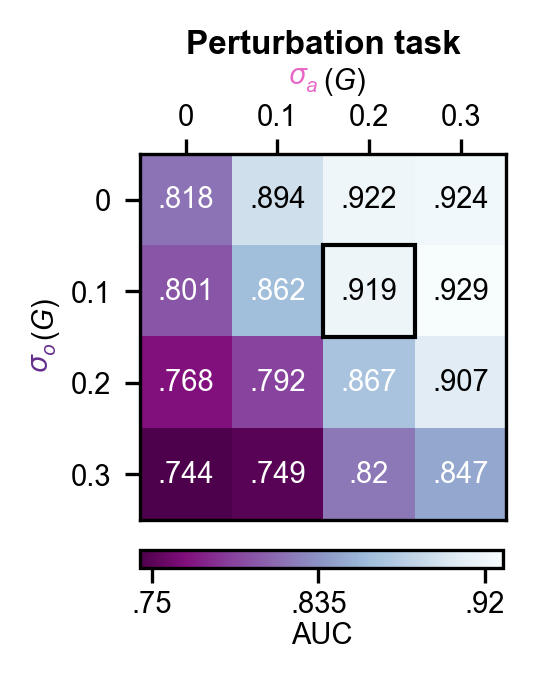

In [28]:
xticks = np.arange(len(obs_stds)); xticklabels = obs_stds
yticks = np.arange(len(pro_stds)); yticklabels = pro_stds
width = 1.7
height = 2.2

with initiate_plot(width, height, 300) as fig:
    ax = fig.add_subplot(111)
    ax.set_title('Perturbation task', fontsize=fontsize + 1, fontweight='bold', pad=3)
    plt.xticks(xticks, xticklabels, fontsize=fontsize)
    plt.yticks(yticks, yticklabels, fontsize=fontsize)
    ax.set_xlabel(r'$\sigma_a$', fontsize=fontsize, c=motor_c)
    ax.set_ylabel(r'$\sigma_o$', fontsize=fontsize, c=sensory_c)
    ax.xaxis.set_label_coords(0.445, 1.24)
    ax.yaxis.set_label_coords(-0.22, 0.445)
        
    cmatplot = ax.matshow(auc_noise_pert_mean, cmap='BuPu_r') 
    ax.tick_params(axis='x', which='major', pad=2, bottom=False)
    cbaxes = ax.inset_axes([0, -0.13, 0.99, 0.05]) 
    cbar = fig.colorbar(cmatplot, cax=cbaxes, orientation='horizontal')
    cbar.ax.tick_params(labelsize=fontsize, pad=2)
    cbar_ticks = [0.75, 0.835, 0.92]
    cbar.set_ticks(cbar_ticks)
    cbar.set_label('AUC', fontsize=fontsize)
    cbar.ax.xaxis.set_label_coords(0.5, -2.9)
    cbar.ax.xaxis.set_major_formatter(major_formatter)
    
    rect = Rectangle(xy=(1.5, 0.5), width=1, height=1, fill=False, ec='k', lw=1)
    ax.add_patch(rect)
    
    for iy, y in enumerate(np.arange(len(yticks))):
        for ix, x in enumerate(np.arange(len(xticks))):
            v = round(auc_noise_pert_mean[iy][ix], 3)
            c = 'k' if v > 0.89 else 'w' 
            ax.text(x, y, s='.' + str(v).split('.')[1], fontsize=fontsize, 
                    c=c, va='center', ha='center')
            
    ax.text(1.5, -1.2, '$(G)$', fontsize=fontsize)
    ax.text(-1.7, 1.45, '$(G)$', fontsize=fontsize, rotation='vertical')
    
    fig.tight_layout(pad=0.3, rect=(-0.01, 0.02, 0.99, 1.02))
    
    #plt.savefig('C:/Users/rz31/Desktop/paper_figures/figure7/raw/{name}.pdf'.format(
    #             name='auc_pert'), orientation='portrait', format='pdf', transparent=True)

## sup b

In [29]:
_ = [[get_neural_response(agent, df) for agent, df in zip(agents_, dfs)] 
     for agents_, dfs in zip(noise_agents_pert, noise_agent_trajectories_pert)]

In [30]:
decoders_pert = [list(map(fit_decoder, dfs)) for dfs in noise_agent_trajectories_pert]
decoding_errors_pert = [[np.linalg.norm(deco[0].predict(deco[1]) - deco[2], axis=1).mean() for deco in decoder]
                        for decoder in decoders_pert]
decoding_errors_pert_mean = np.array([np.mean(v) for v in decoding_errors_pert]).reshape(len(obs_stds), len(pro_stds))
decoding_errors_pert_sem = np.array([sem(v) for v in decoding_errors_pert]).reshape(len(obs_stds), len(pro_stds))

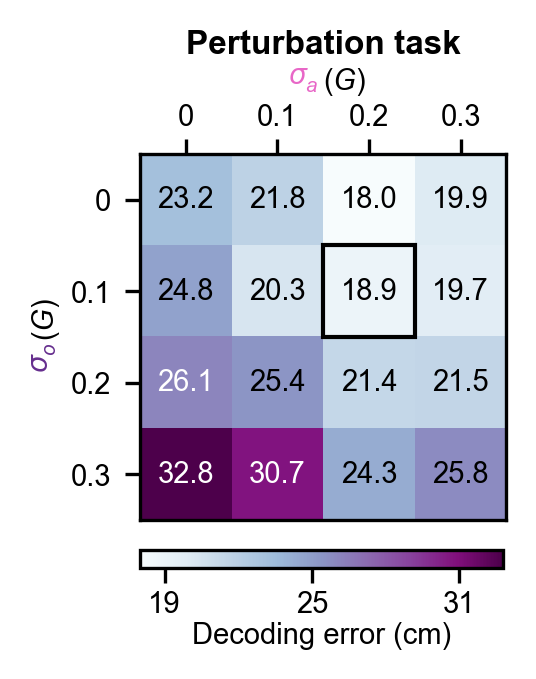

In [31]:
xticks = np.arange(len(obs_stds)); xticklabels = obs_stds
yticks = np.arange(len(pro_stds)); yticklabels = pro_stds
width = 1.7
height = 2.2

with initiate_plot(width, height, 300) as fig:
    ax = fig.add_subplot(111)
    ax.set_title('Perturbation task', fontsize=fontsize + 1, fontweight='bold', pad=3)
    plt.xticks(xticks, xticklabels, fontsize=fontsize)
    plt.yticks(yticks, yticklabels, fontsize=fontsize)
    ax.set_xlabel(r'$\sigma_a$', fontsize=fontsize, c=motor_c)
    ax.set_ylabel(r'$\sigma_o$', fontsize=fontsize, c=sensory_c)
    ax.xaxis.set_label_coords(0.445, 1.24)
    ax.yaxis.set_label_coords(-0.22, 0.445)
        
    cmatplot = ax.matshow(decoding_errors_pert_mean, cmap='BuPu') 
    ax.tick_params(axis='x', which='major', pad=2, bottom=False)
    cbaxes = ax.inset_axes([0, -0.13, 0.99, 0.05]) 
    cbar = fig.colorbar(cmatplot, cax=cbaxes, orientation='horizontal')
    cbar.ax.tick_params(labelsize=fontsize, pad=2)
    cbar_ticks = [19, 25, 31]
    cbar.set_ticks(cbar_ticks)
    cbar.set_label('Decoding error (cm)', fontsize=fontsize)
    cbar.ax.xaxis.set_label_coords(0.5, -2.9)
    cbar.ax.xaxis.set_major_formatter(major_formatter)
    
    rect = Rectangle(xy=(1.5, 0.5), width=1, height=1, fill=False, ec='k', lw=1)
    ax.add_patch(rect)
    
    for iy, y in enumerate(np.arange(len(yticks))):
        for ix, x in enumerate(np.arange(len(xticks))):
            v = round(decoding_errors_pert_mean[iy][ix], 1)
            c = 'k' if v < 26 else 'w'
            ax.text(x, y, s=v, fontsize=fontsize, 
                    c=c, va='center', ha='center')
            
    ax.text(1.5, -1.2, '$(G)$', fontsize=fontsize)
    ax.text(-1.7, 1.45, '$(G)$', fontsize=fontsize, rotation='vertical')
    
    fig.tight_layout(pad=0.3, rect=(-0.01, 0.02, 0.99, 1.02))
    
    #plt.savefig('C:/Users/rz31/Desktop/paper_figures/figure7/raw/{name}.pdf'.format(
    #             name='sup_decoding_error_pert'), orientation='portrait', format='pdf', transparent=True)

## sup d

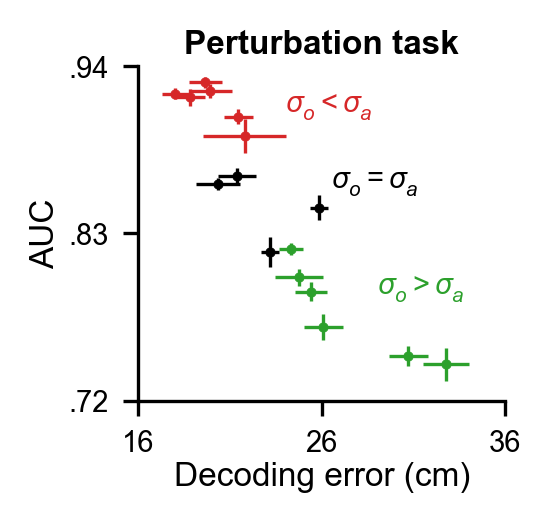

In [32]:
width = 1.7; height = 1.6
marker = 'o'; marker_size = 5; marker_lw = lw * 0.2

xticks = [16, 26, 36]
yticks = [0.72, 0.83, 0.94]

indices_upper, indices_lower, indices_diag = get_index_upper_lower_diag(auc_noise_pert_mean)
colors = ['C3', 'C2', 'k']

with initiate_plot(width, height, 300) as fig:
    ax = fig.add_subplot(1, 1, 1)
    ax.set_title('Perturbation task', fontsize=fontsize + 1, fontweight='bold', pad=3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.xticks(xticks, fontsize=fontsize)
    plt.yticks(yticks, fontsize=fontsize)
    ax.set_xlabel('Decoding error (cm)', fontsize=fontsize + 1)
    ax.set_ylabel(r'AUC', fontsize=fontsize + 1)
    ax.set_xlim(xticks[0], xticks[-1])
    ax.set_ylim(yticks[0], yticks[-1])
    ax.xaxis.set_label_coords(0.5, -0.18)
    ax.yaxis.set_label_coords(-0.21, 0.5)
    ax.xaxis.set_major_formatter(major_formatter)
    ax.yaxis.set_major_formatter(major_formatter)

    for agent_idx in range(auc_noise_pert_mean.size):
        if agent_idx in indices_upper:
            c = colors[0]
        elif agent_idx in indices_lower:
            c = colors[1]
        elif agent_idx in indices_diag:
            c = colors[2]

        ax.scatter(decoding_errors_pert_mean.flatten()[agent_idx], auc_noise_pert_mean.flatten()[agent_idx], 
                   s=marker_size, lw=marker_lw, marker=marker, clip_on=False, c=c)
        ax.errorbar(decoding_errors_pert_mean.flatten()[agent_idx], auc_noise_pert_mean.flatten()[agent_idx], 
                    yerr=auc_noise_pert_sem.flatten()[agent_idx], xerr=decoding_errors_pert_sem.flatten()[agent_idx], 
                    c=c, lw=lw * 0.8, ls='none') 
        
    ax.text(24, 0.91, '$\sigma_o<\sigma_a$', fontsize=fontsize, c=colors[0])
    ax.text(26.5, 0.86, '$\sigma_o=\sigma_a$', fontsize=fontsize, c=colors[2])
    ax.text(29, 0.79, '$\sigma_o>\sigma_a$', fontsize=fontsize, c=colors[1])
           
    fig.tight_layout(pad=0.15, rect=(0, 0, 1, 1))

    #plt.savefig('C:/Users/rz31/Desktop/paper_figures/figure7/raw/{name}.pdf'.format(
    #    name='sup_corr_pert'), orientation='portrait', format='pdf', transparent=True)